In [1]:
# Importando as bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


In [2]:
# Carregando o dataset da clínica
df = pd.read_csv("dataset_clinica.csv")

# Visualizando as primeiras linhas
df.head()

,id_consulta,id_paciente,id_medico,id_especialidade,especialidade,data_agendamento,data_consulta,hora_consulta,status_consulta,valor_consulta
0,1,1,1,1,Cardiologia,2026-02-20,2026-03-02,09:00:00,Realizada,220.0
1,2,2,2,2,Pediatria,2026-02-21,2026-03-02,14:00:00,Realizada,200.0
2,3,3,3,3,Ortopedia,2026-02-22,2026-03-03,09:30:00,Realizada,210.0
3,4,4,4,4,Dermatologia,2026-02-23,2026-03-03,14:30:00,Realizada,220.0
4,5,5,5,5,Ginecologia,2026-02-24,2026-03-04,09:00:00,Realizada,210.0


In [3]:
# Verificando informações do dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id_consulta       20 non-null     int64  
 1   id_paciente       20 non-null     int64  
 2   id_medico         20 non-null     int64  
 3   id_especialidade  20 non-null     int64  
 4   especialidade     20 non-null     object 
 5   data_agendamento  20 non-null     object 
 6   data_consulta     20 non-null     object 
 7   hora_consulta     20 non-null     object 
 8   status_consulta   20 non-null     object 
 9   valor_consulta    20 non-null     float64
dtypes: float64(1), int64(4), object(5)
memory usage: 1.7+ KB


**A análise da estrutura do dataset mostra que a base possui 20 registros e 10 colunas. Todas as colunas estão preenchidas, sem valores nulos. Também foi possível identificar os tipos dos dados, sendo necessário converter as colunas de data para o formato adequado antes das próximas etapas da análise.**

In [4]:
# Verificando valores nulos
df.isnull().sum()

,0
id_consulta,0
id_paciente,0
id_medico,0
id_especialidade,0
especialidade,0
data_agendamento,0
data_consulta,0
hora_consulta,0
status_consulta,0
valor_consulta,0


**A verificação de valores nulos mostrou que todas as colunas possuem dados preenchidos. Como não foram identificados valores ausentes, não foi necessário realizar preenchimento ou remoção de registros nessa etapa do tratamento.**

In [5]:
# Convertendo as colunas de data
df["data_agendamento"] = pd.to_datetime(df["data_agendamento"])
df["data_consulta"] = pd.to_datetime(df["data_consulta"])

# Criando a quantidade de dias entre o agendamento e a consulta
df["dias_ate_consulta"] = (
    df["data_consulta"] - df["data_agendamento"]
).dt.days

df.head()

,id_consulta,id_paciente,id_medico,id_especialidade,especialidade,data_agendamento,data_consulta,hora_consulta,status_consulta,valor_consulta,dias_ate_consulta
0,1,1,1,1,Cardiologia,2026-02-20,2026-03-02,09:00:00,Realizada,220.0,10
1,2,2,2,2,Pediatria,2026-02-21,2026-03-02,14:00:00,Realizada,200.0,9
2,3,3,3,3,Ortopedia,2026-02-22,2026-03-03,09:30:00,Realizada,210.0,9
3,4,4,4,4,Dermatologia,2026-02-23,2026-03-03,14:30:00,Realizada,220.0,8
4,5,5,5,5,Ginecologia,2026-02-24,2026-03-04,09:00:00,Realizada,210.0,8


**As colunas de data foram convertidas para o formato correto. Em seguida, foi criada a variável dias_ate_consulta, que mostra quantos dias existem entre o agendamento e a realização da consulta.**

In [6]:
# Criando a variável que identifica falta do paciente
df["no_show"] = df["status_consulta"].apply(
    lambda status: 1 if status == "Faltou" else 0
)

df[["status_consulta", "no_show"]]

,status_consulta,no_show
0,Realizada,0
1,Realizada,0
2,Realizada,0
3,Realizada,0
4,Realizada,0
5,Realizada,0
6,Realizada,0
7,Realizada,0
8,Realizada,0
9,Realizada,0


**Foi criada a variável no_show para representar o comparecimento do paciente de forma numérica. As consultas com status “Faltou” receberam o valor 1, enquanto os demais status receberam o valor 0. Essa variável será utilizada como resultado que o modelo de Machine Learning deverá prever.**

In [7]:
# Conferindo a quantidade de faltas
df["no_show"].value_counts()

,count
no_show,
0,19
1,1


**A contagem da variável no_show mostrou que 19 consultas não tiveram falta e apenas 1 apresentou ausência do paciente. Esse resultado evidencia que a base está desbalanceada, com predominância de consultas sem no-show, o que deve ser considerado na interpretação do modelo de Machine Learning.**

In [8]:
# Ordenando as consultas por paciente e data
df = df.sort_values(["id_paciente", "data_consulta"])

# Criando o histórico de faltas anteriores de cada paciente
df["historico_faltas"] = (
    df.groupby("id_paciente")["no_show"]
      .transform(lambda x: x.shift(fill_value=0).cumsum())
)

df[["id_paciente", "data_consulta", "status_consulta",
    "no_show", "historico_faltas"]]

,id_paciente,data_consulta,status_consulta,no_show,historico_faltas
0,1,2026-03-02,Realizada,0,0
12,1,2026-03-09,Realizada,0,0
1,2,2026-03-02,Realizada,0,0
13,2,2026-09-07,Agendada,0,0
2,3,2026-03-03,Realizada,0,0
14,3,2026-03-09,Realizada,0,0
3,4,2026-03-03,Realizada,0,0
15,4,2026-03-14,Realizada,0,0
4,5,2026-03-04,Realizada,0,0
16,5,2026-03-21,Cancelada,0,0


**Foi criada a variável historico_faltas, que representa a quantidade de faltas anteriores de cada paciente. Essa informação poderá ser utilizada pelo modelo para analisar se o histórico do paciente influencia o risco de não comparecimento.**

In [9]:
# Análise com NumPy
media_dias = np.mean(df["dias_ate_consulta"])
desvio_dias = np.std(df["dias_ate_consulta"])

print("Média de dias de antecedência:", round(media_dias, 2))
print("Desvio padrão:", round(desvio_dias, 2))

Média de dias de antecedência: 7.85
Desvio padrão: 1.93


**Foi calculada a média e o desvio padrão dos dias de antecedência das consultas. A média representa o tempo médio entre o agendamento e a data da consulta, enquanto o desvio padrão mostra a variação desse período entre os atendimentos.**

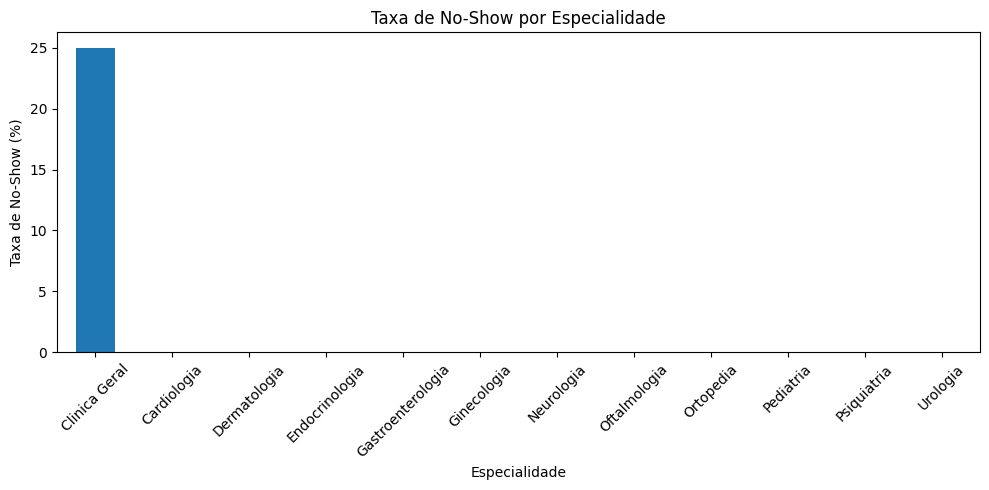

In [10]:
# Taxa de no-show por especialidade
taxa_no_show = df.groupby("especialidade")["no_show"].mean() * 100

plt.figure(figsize=(10, 5))
taxa_no_show.sort_values(ascending=False).plot(kind="bar")

plt.title("Taxa de No-Show por Especialidade")
plt.xlabel("Especialidade")
plt.ylabel("Taxa de No-Show (%)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

**O gráfico permite comparar a taxa de faltas entre as especialidades. Na base analisada, apenas uma consulta foi registrada como falta, por isso somente a especialidade vinculada a esse atendimento apresentou taxa de no-show, enquanto as demais não tiveram faltas registradas.**

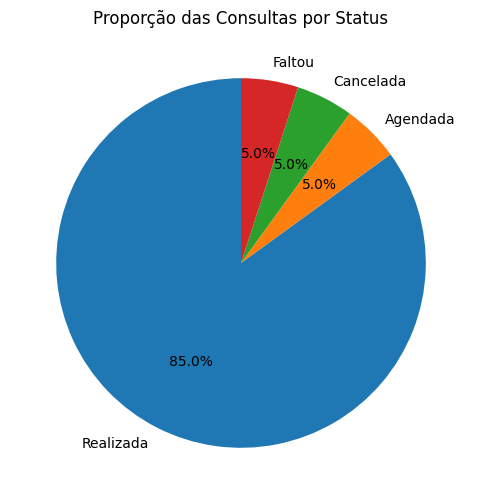

In [11]:
# Proporção de consultas realizadas e faltas

dados_pizza = df["status_consulta"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    dados_pizza,
    labels=dados_pizza.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Proporção das Consultas por Status")
plt.show()

**O gráfico apresenta a distribuição das consultas de acordo com o status registrado. Observa-se predominância de atendimentos realizados, enquanto os registros de falta, cancelamento e agendamento representam uma parcela menor do total. Esse resultado permite visualizar de forma rápida o comportamento dos atendimentos na clínica.**

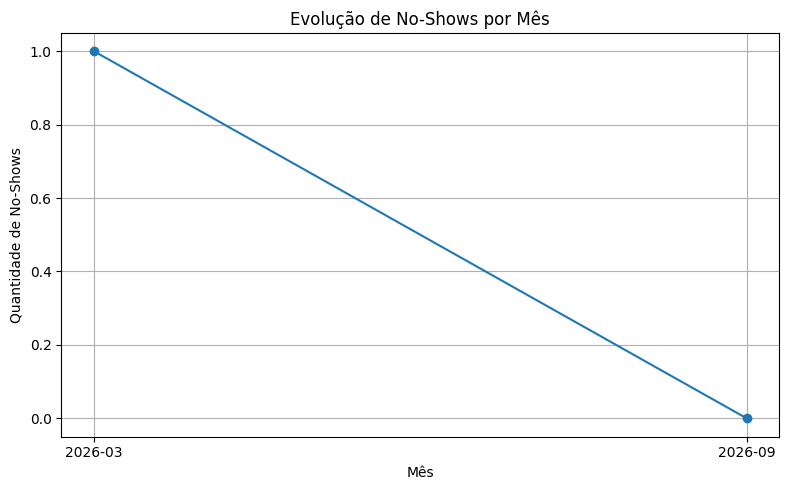

In [12]:
# Evolução dos no-shows ao longo dos meses

df["mes_consulta"] = df["data_consulta"].dt.to_period("M").astype(str)

no_show_mes = df.groupby("mes_consulta")["no_show"].sum()

plt.figure(figsize=(8, 5))
plt.plot(no_show_mes.index, no_show_mes.values, marker="o")

plt.title("Evolução de No-Shows por Mês")
plt.xlabel("Mês")
plt.ylabel("Quantidade de No-Shows")
plt.grid(True)
plt.tight_layout()

plt.show()

**O gráfico apresenta a evolução mensal dos registros de no-show. Na base analisada, foi identificado apenas um caso de falta, concentrado em um único período. Esse acompanhamento mensal pode auxiliar a clínica na identificação de possíveis variações no comportamento de comparecimento dos pacientes ao longo do tempo.**

In [13]:
# Salvando o dataset tratado
df.to_csv("dataset_clinica_limpo.csv", index=False)

print("Dataset salvo com sucesso!")

Dataset salvo com sucesso!


In [14]:
df.head()

,id_consulta,id_paciente,id_medico,id_especialidade,especialidade,data_agendamento,data_consulta,hora_consulta,status_consulta,valor_consulta,dias_ate_consulta,no_show,historico_faltas,mes_consulta
0,1,1,1,1,Cardiologia,2026-02-20,2026-03-02,09:00:00,Realizada,220.0,10,0,0,2026-03
12,25,1,1,1,Cardiologia,2026-03-01,2026-03-09,10:00:00,Realizada,220.0,8,0,0,2026-03
1,2,2,2,2,Pediatria,2026-02-21,2026-03-02,14:00:00,Realizada,200.0,9,0,0,2026-03
13,26,2,1,1,Cardiologia,2026-08-30,2026-09-07,08:30:00,Agendada,220.0,8,0,0,2026-09
2,3,3,3,3,Ortopedia,2026-02-22,2026-03-03,09:30:00,Realizada,210.0,9,0,0,2026-03


In [15]:
df.shape

(20, 14)

**A base utilizada foi extraída diretamente do banco de dados ClínicaCare. Como o conjunto possui poucos registros e apenas um caso de no-show, o modelo desenvolvido terá finalidade demonstrativa, permitindo aplicar as etapas de preparação, treinamento e classificação dos dados.**

In [17]:
# Selecionando as variáveis que serão utilizadas no modelo

X = df[
    [
        "dias_ate_consulta",
        "historico_faltas",
        "especialidade"
    ]
]

# Variável que o modelo deverá prever
y = df["no_show"]

X.head()

,dias_ate_consulta,historico_faltas,especialidade
0,10,0,Cardiologia
12,8,0,Cardiologia
1,9,0,Pediatria
13,8,0,Cardiologia
2,9,0,Ortopedia


**Foram selecionadas as variáveis dias_ate_consulta, historico_faltas e especialidade como características de entrada do modelo. A variável no_show foi definida como o resultado que será previsto. Essa seleção permite que o modelo analise fatores relacionados ao agendamento, ao comportamento anterior do paciente e à especialidade da consulta.**

In [18]:
# Transformando a especialidade em variáveis numéricas

X = pd.get_dummies(
    X,
    columns=["especialidade"],
    drop_first=False
)

X.head()

,dias_ate_consulta,historico_faltas,especialidade_Cardiologia,especialidade_Clinica Geral,especialidade_Dermatologia,especialidade_Endocrinologia,especialidade_Gastroenterologia,especialidade_Ginecologia,especialidade_Neurologia,especialidade_Oftalmologia,especialidade_Ortopedia,especialidade_Pediatria,especialidade_Psiquiatria,especialidade_Urologia
0,10,0,True,False,False,False,False,False,False,False,False,False,False,False
12,8,0,True,False,False,False,False,False,False,False,False,False,False,False
1,9,0,False,False,False,False,False,False,False,False,False,True,False,False
13,8,0,True,False,False,False,False,False,False,False,False,False,False,False
2,9,0,False,False,False,False,False,False,False,False,True,False,False,False


**Foram selecionadas as variáveis dias até a consulta, histórico de faltas e especialidade para o treinamento do modelo. Como a especialidade é uma variável categórica, seus valores foram convertidos para formato numérico, permitindo sua utilização pelo algoritmo de Machine Learning.**

In [19]:
# Importando o normalizador
from sklearn.preprocessing import StandardScaler

# Normalizando as variáveis do modelo
scaler = StandardScaler()

X_normalizado = scaler.fit_transform(X)

print("Dados normalizados com sucesso!")

Dados normalizados com sucesso!


**Os dados foram normalizados para colocar as variáveis em uma mesma escala. Essa etapa ajuda o algoritmo de Machine Learning a trabalhar de forma mais adequada com características que possuem valores diferentes.**

In [20]:
# Separando os dados em treino e teste

from sklearn.model_selection import train_test_split

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X_normalizado,
    y,
    test_size=0.25,
    random_state=42
)

print("Dados de treino:", len(X_treino))
print("Dados de teste:", len(X_teste))

print("\nNo-show no treino:")
print(y_treino.value_counts())

print("\nNo-show no teste:")
print(y_teste.value_counts())

Dados de treino: 15
Dados de teste: 5

No-show no treino:
no_show
0    14
1     1
Name: count, dtype: int64

No-show no teste:
no_show
0    5
Name: count, dtype: int64


**Os dados foram divididos em conjuntos de treino e teste. O conjunto de treino será utilizado para ensinar o modelo a identificar padrões, enquanto o conjunto de teste será utilizado para avaliar seu comportamento com dados que não participaram do treinamento.**

In [21]:
# Treinando o modelo de Machine Learning

from sklearn.linear_model import LogisticRegression

modelo = LogisticRegression(
    class_weight="balanced",
    random_state=42
)

modelo.fit(X_treino, y_treino)

print("Modelo treinado com sucesso!")

Modelo treinado com sucesso!


**Foi utilizado o modelo de Regressão Logística para realizar a classificação do no-show. O modelo foi treinado com os dados da ClínicaCare e foi aplicado um balanceamento das classes devido à baixa quantidade de registros de falta na base analisada.**

In [22]:
# Realizando previsões com o modelo

y_previsto = modelo.predict(X_teste)

print("Previsões realizadas com sucesso!")
print(y_previsto)

Previsões realizadas com sucesso!
[0 0 0 0 0]


In [23]:
# Avaliando o modelo

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

acuracia = accuracy_score(y_teste, y_previsto)

print("Acurácia:", round(acuracia, 2))

print("\nMatriz de confusão:")
print(confusion_matrix(y_teste, y_previsto))

print("\nRelatório de classificação:")
print(classification_report(y_teste, y_previsto, zero_division=0))

Acurácia: 1.0

Matriz de confusão:
[[5]]

Relatório de classificação:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


**O modelo apresentou acurácia de 100% no conjunto de teste, classificando corretamente os cinco registros avaliados. Entretanto, esse resultado deve ser interpretado com cautela, pois o conjunto de teste contém apenas consultas sem ocorrência de no-show. A baixa quantidade de registros de falta na base limita a avaliação do desempenho do modelo para identificar pacientes com risco de não comparecimento. Portanto, os resultados apresentados possuem finalidade demonstrativa.**

In [26]:
print("Critério de classificação:")
print("Probabilidade menor que 50% = Baixo Risco")
print("Probabilidade igual ou maior que 50% = Alto Risco")

resultado_risco.head(10)

Critério de classificação:
Probabilidade menor que 50% = Baixo Risco
Probabilidade igual ou maior que 50% = Alto Risco


,id_consulta,especialidade,probabilidade_no_show,risco_no_show
0,1,Cardiologia,18.22,Baixo Risco
12,25,Cardiologia,5.13,Baixo Risco
1,2,Pediatria,7.31,Baixo Risco
13,26,Cardiologia,5.13,Baixo Risco
2,3,Ortopedia,7.86,Baixo Risco
14,27,Pediatria,1.88,Baixo Risco
3,4,Dermatologia,4.07,Baixo Risco
15,28,Clinica Geral,33.91,Baixo Risco
4,5,Ginecologia,6.29,Baixo Risco
16,29,Clinica Geral,67.87,Alto Risco


**O modelo calcula a probabilidade de no-show para cada consulta. Com base nesse valor, as consultas com probabilidade inferior a 50% são classificadas como Baixo Risco, enquanto aquelas com probabilidade igual ou superior a 50% são classificadas como Alto Risco. Em seguida, são exibidos os primeiros registros para facilitar a análise dos resultados.**

In [27]:
# Resumo da classificação de risco
df["risco_no_show"].value_counts()

,count
risco_no_show,
Baixo Risco,18
Alto Risco,2


**A classificação de risco identificou 18 consultas como Baixo Risco e 2 como Alto Risco de no-show. Esse resultado permite destacar os atendimentos com maior probabilidade de ausência e pode auxiliar a clínica na adoção de ações preventivas, como confirmação antecipada da consulta.**

In [28]:
# Salvando o dataset final com as previsões
df.to_csv("dataset_clinica_limpo.csv", index=False)

print("Dataset final salvo com sucesso!")

Dataset final salvo com sucesso!


**Após o tratamento dos dados e a aplicação do modelo de Machine Learning, o dataset final foi salvo em formato CSV. O arquivo contém os dados originais da ClínicaCare, as variáveis criadas durante a análise e os resultados da classificação de risco de no-show.**

**Conclusão**: A análise utilizou dados extraídos do banco ClínicaCare para avaliar o comportamento de comparecimento dos pacientes. Foram realizadas etapas de tratamento, transformação, visualização e aplicação de Machine Learning. O modelo classificou as consultas em níveis de risco de no-show e demonstrou como os dados da clínica podem ser utilizados para apoiar análises preditivas. Como a base possui poucos registros e apenas um caso de falta, os resultados devem ser considerados demonstrativos. Com um volume maior de dados históricos, o modelo poderá apresentar resultados mais representativos